In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load velocity data
vel_df = pd.read_csv(
    "../Data/whillans_events_with_velocity.csv",
    parse_dates=["start_time"]
)

vel_df = vel_df.sort_values("start_time").reset_index(drop=True)

# Find 30-day smoothed velocity columns
v30d_cols = [c for c in vel_df.columns if c.startswith("v30d_")]

# Compute mean 30-day smoothed velocity across stations
vel_df["mean_velocity_30d"] = vel_df[v30d_cols].mean(axis=1, skipna=True)

# Break velocity line across large gaps
# If there is a gap larger than 45 days, make the next value NaN
# so matplotlib does not draw a fake connecting line.
vel_df["time_gap_days"] = vel_df["start_time"].diff().dt.days

vel_df.loc[
    vel_df["time_gap_days"] > 45,
    "mean_velocity_30d"
] = pd.NA

/tmp/ipykernel_29179/792994608.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vel_df["mean_velocity_30d"] = vel_df[v30d_cols].mean(axis=1, skipna=True)
/tmp/ipykernel_29179/792994608.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vel_df["time_gap_days"] = vel_df["start_time"].diff().dt.days


In [ ]:

# Load time-to-next-event data
event_df = pd.read_csv(
    "../Data/filtered_time_to_next_event.csv",
    parse_dates=["ev_time_utc"]
)

event_df = event_df.sort_values("ev_time_utc").reset_index(drop=True)

# Smooth event timing for readability

# Raw time-to-next-event is very noisy because events happen frequently.
# A 30-day rolling median shows the broader trend more clearly.
event_df = event_df.set_index("ev_time_utc").sort_index()

event_df["time_to_next_30d"] = (
    event_df["time_to_next_ev_hr"]
    .rolling("30D", min_periods=5)
    .median()
)

event_df = event_df.reset_index()

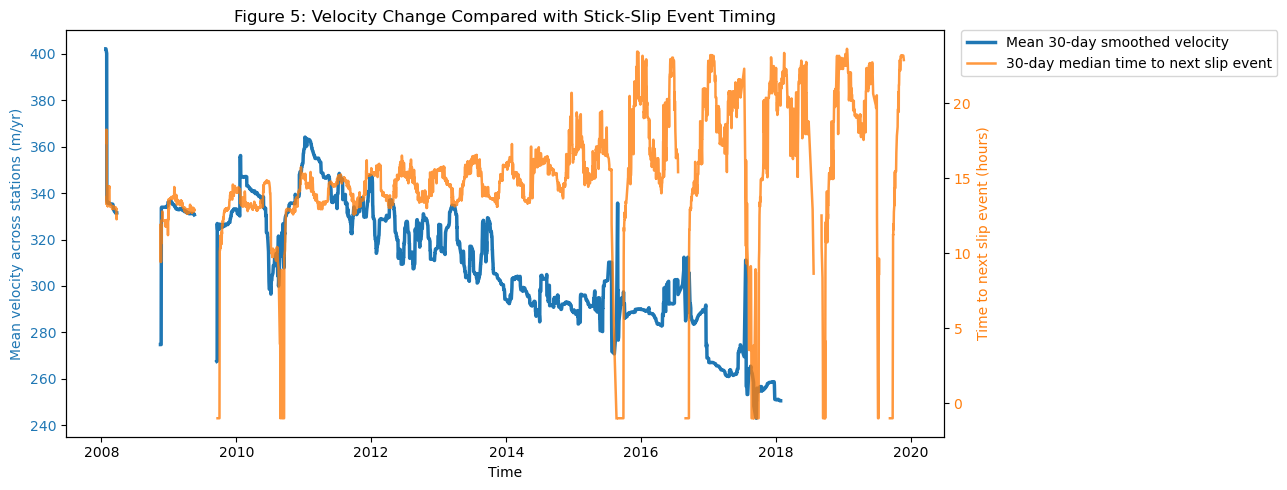

In [ ]:

# Figure 5: velocity and time-to-next-event
fig, ax1 = plt.subplots(figsize=(13, 5))

# Left axis: mean 30-day smoothed velocity
line1 = ax1.plot(
    vel_df["start_time"],
    vel_df["mean_velocity_30d"],
    color="tab:blue",
    linewidth=2.5,
    label="Mean 30-day smoothed velocity"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Mean velocity across stations (m/yr)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right axis: smoothed time to next event
ax2 = ax1.twinx()

line2 = ax2.plot(
    event_df["ev_time_utc"],
    event_df["time_to_next_30d"],
    color="tab:orange",
    linewidth=1.8,
    alpha=0.8,
    label="30-day median time to next slip event"
)

ax2.set_ylabel("Time to next slip event (hours)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Combine legends
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels, 
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True)

ax1.set_title("Figure 5: Velocity Change Compared with Stick-Slip Event Timing")

plt.tight_layout()

plt.savefig(
    "../images/figure5_velocity_vs_event_timing_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 5 Interpertation: 

Figure 5 compares changes in mean ice velocity with the timing between stick-slip events from 2008 to 2018. The blue line shows the mean 30-day smoothed velocity across all stations, while the orange line shows the 30-day median time to the next slip event. Overall, there is a noticeable inverse relationship between velocity and event timing. When the ice velocity is relatively high (around 2010–2012), the time between slip events tends to be shorter, indicating more frequent stick-slip behavior. As velocity gradually decreases after about 2013, the time between events generally increases, meaning slip events become less frequent. This pattern suggests that faster-moving ice is associated with more frequent slip events, while slower-moving ice corresponds to longer intervals between events. The smoothed lines make this relationship easier to see by reducing short-term variability. Although the relationship is not perfectly consistent at all times, the overall trend supports the idea that changes in ice velocity are linked to changes in stick-slip event frequency across the Whillans Ice Plain.